# AAA in Maple #

This Jupyter notebook contains Maple code (licensed by the MIT license below) to explore the use of the Adaptive Antoulas Anderson method of rational approximation to approximate the Lambert $W$ function, specifically the principal branch on the interval $-1/e < x < e$.

© Robert M. Corless 2026 (MIT Release licence)

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


Lambert $W_0$ on $-\exp(-1) \le x \le \exp(1)$

In [1]:
#
# AAA, the Adaptive Antoulas-Anderson method of rational approximation
# 
# See Nakatsukasa, Se`te, & Trefethen, SISC 2018
# DOI. 10.1137/16M1106122
#
# Maple program by Robert M. Corless December 2020
# working both from that paper and from the Matlab code in that paper
#
AAA := proc( F::Vector, s::name, 
             Zin::Vector, 
             {tol::And(numeric,positive):=10.0^(2-Digits)},
             {mmax::posint:=1000}, $ )
  local A, C, Deno, err, errvec, f, i, J, j, k, 
        M, m, normF, Nume, R, ratfit, SF, Sf, VT, w, Z, z;
  if Digits < 15 then
    warning("Using less than 15 Digits, perhaps unintentionally")
  fi;
  Z := evalf( convert(Zin,Vector) );
  M := numelems(Z);
  #Fn := unapply( Fns, s );
  #F := evalf( map( Fn, Z ) ); # Damn the indexing
  J := [ seq(k,k=1..M) ]; # index of unchosen samples
  z := Array(1..mmax); # chosen samples
  C := Matrix(M,mmax); # Cauchy matrix
  f := Array(1..mmax); # chosen "large" function values
  errvec := Array(1..mmax); # Vector of errors at each step 
  use LinearAlgebra in
    normF := Norm(F,infinity);
    SF := Matrix(M,M, 'storage'='sparse'); # Left scaling matrix
    for i to M do 
      SF[i,i] := F[i]; 
    od;
    R := add(f, f in F )/M; # Initial rational approximation
    R := Vector(M, R);   # R is now the value of that approx
    for m to mmax do # Main loop
      j := max[index]( Vector(M, ii->abs(F[ii]-R[ii]) ) );
      J := remove(t->t=j,J); # Update list of unchosen samples
      if numelems(J)=0 then
      	print( "Ran out of sample points") ;
      	m := m-1;
      	break;
      end if;
      z[m] := Z[j];
      f[m] := F[j];
      # Next column of Cauchy matrix
      for k in J do
        C[k,m] := 1.0/(Z[k]-z[m]); # Float(infinity) if k=j 
      od;
      Sf := DiagonalMatrix([seq(f[k],k=1..m)]);
      A := SF.C[1..-1,1..m] - C[1..-1,1..m].Sf; # Loewner matrix
      A := Matrix(numelems(J),m, 'datatype'=complex(numeric), (ii,jj)->evalf(A[J[ii],jj]) ); 
      VT := SingularValues( A, 'output'=['Vt']);
      w := Vector(m, ii->VT[m,ii]); # Maple doesn't have sparse SVD
      Nume := C[1..-1,1..m].Vector(m,ii->w[ii]*f[ii]);
      Deno := C[1..-1,1..m].Vector(m,ii->w[ii]);
      R := copy(F); # When z=z[j] leave interpolated value in vector
      for k in J do
        R[k] := Nume[k]/Deno[k]; # Everything else is interpolant
      od;
      err := Norm( R-F, infinity );
      errvec[m] := err;
      if err < tol*normF then
        break;
      fi;
    od;
  end use;
  ratfit := add( w[k]*f[k]/(s-z[k]), k=1..m)/add( w[k]/(s-z[k]), k=1..m);
  return ratfit, Vector(m,[seq(w[k],k=1..m)]), Vector(m,[seq(f[k],k=1..m)]), 
                 Vector(m,[seq(z[k],k=1..m)]), Vector(m,[seq(errvec[k],k=1..m)]) 
end proc:

kilobytes used=3527, alloc=9776, time=0.66

In [2]:
Digits := 15:
nsamples := 233:
L := -1.0:  U := 1.0:
rfloat := (i->L+(U-L)*(i-1)/(nsamples-1)):
dt := float[8]:
wvals := Vector( nsamples, datatype=dt, i->rfloat(i)):
Z := Vector( nsamples, datatype=dt, i->wvals[i]*exp(wvals[i]) ):
F := Vector( nsamples, datatype=dt, i->wvals[i] ):
tmp := Vector(nsamples, datatype=dt):
skip := Vector(nsamples, datatype=dt):
nmax := 250: # make sure it's the same in evalhfcfrac and evalhftcf
aa := Vector(nmax,datatype=dt):
ss := Vector(nmax,datatype=dt,1):
zz := Vector(nmax,datatype=dt):
phi := Vector(nmax,datatype=dt):
err := Vector(nmax,datatype=dt):
tol := Float(1,-13)/8.0:
k := Vector(1,datatype=dt);
eqtm := 1:

                                   k := [0.]

In [3]:
nsamples;

$$233$$

In [4]:
min(Z), max(Z);

$$- 0.367879441171442334$$,$$ 2.71828182845904509$$

In [5]:
min(F), max(F);

$$- 1.0$$,$$ 1.0$$

In [6]:
samplot := plot( [seq([Z[k],wvals[k]], k=1..nsamples)], style=point ):
Wplot := plot( [y*exp(y),y,y=min(F)..max(F)]):

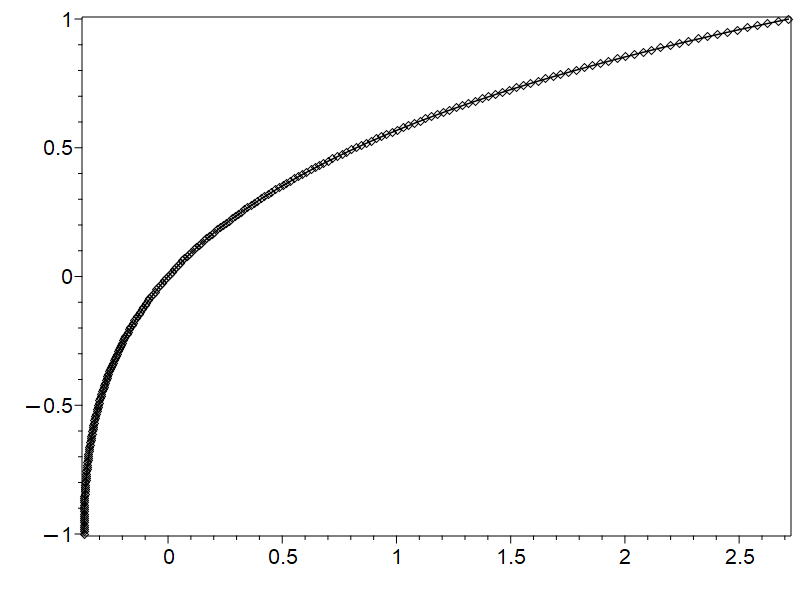

In [7]:
plots[display]( Wplot, samplot );

In [8]:
(R,wts,fvals,nodes,errs) := CodeTools:-Usage( AAA(F,s,Z,
'tol'=0.125*10^(2-Digits)) ):

memory used=23.48MiB, alloc change=42.90MiB, cpu time=843.00ms, real time=655.00ms, gc time=218.75ms

In [9]:
max(map(abs,wts))/min(map(abs,wts));

$$ 115277.105051755556$$

In [10]:
numelems(nodes), numelems(fvals), numelems(wts);

$$23$$,$$23$$,$$23$$

In [11]:
latex(evalf[7](convert(nodes,list)));

[- 0.3678794,  2.718282, - 0.3032653,  0.4705648, - 0.3669633,  1.685533, - 0.3635209, - 0.3678241, - 0.2045701, - 0.3552711, - 0.3676556,  0.06409844,  2.491379, - 0.3661170, - 0.3417835, - 0.3673700,  0.9121297, - 0.2735742, - 0.3603641, - 0.07908659, - 0.3678657,  2.197571, - 0.3677543]

In [12]:
Ro := unapply(R,s):

In [13]:
CMPL := proc( p::{list,Vector}, tau::{list,Vector}, gam::{list,Vector}, $ )
   local C0, C1, n, i, j, k, d;
   n := numelems(tau);

   d := n - 1;

   C1 := Matrix( d+2, d+2, (i,j)->`if`(i<>j,0,`if`(i=1,0,1)) );
   C0 := Matrix( d+2, d+2, 0 );
   k := 0;
   for i from 1 to n do
     C0[i+1,i+1]   :=  tau[i];
     C0[i+1,1]     :=  p[i];
     C0[1,i+1]     := -gam[i];
   end do;
   return C0, C1
end proc:

In [14]:
ones := [1.0$numelems(wts)];

| | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|1.0|


In [15]:
(C0,C1) := CMPL( ones, nodes, wts ):
(C0z,C1z) := CMPL( convert(fvals,list), nodes, wts ):

In [16]:
with(LinearAlgebra):
Dimension(C0);

$$24$$,$$24$$

In [17]:
E := Eigenvalues(C0,C1);

In [18]:
finitepoles := [seq(E[k],k=3..numelems(E))];

| | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-82.9755634073417+0.*I|-14.8509500031843+0.*I|-5.65131245183295+0.*I|-2.823419718523+0.*I|-1.64063433977501+0.*I|-1.06506522259895+0.*I|-.761121637173552+0.*I|-.593097640347401+0.*I|-.497795759583688+0.*I|-.442991426383772+0.*I|-.411270224004664+0.*I|-.392869391535051+0.*I|-.382194931536927+0.*I|-.376007964606398+0.*I|-.372428859495662+0.*I|-.370367585635957+0.*I|-.369191524010019+0.*I|-.368532351411334+0.*I|-.36817476937314+0.*I|-.367992319333755+0.*I|-.367909978048583+0.*I|-.367882129432179+0.*I|


In [19]:
Digits := 6:
lprint(map(Re,evalf(finitepoles)));

[-82.9756, -14.8510, -5.65131, -2.82342, -1.64063, -1.06507, -.761122, -.593098, -.497796, -.442991, -.411270, -.392869, -.382195, -.376008, -.372429, -.370368, -.369192, -.368532, -.368175, -.367992, -.367910, -.367882]

In [20]:
lprint(map(Im,evalf(finitepoles/Pi)));

[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]

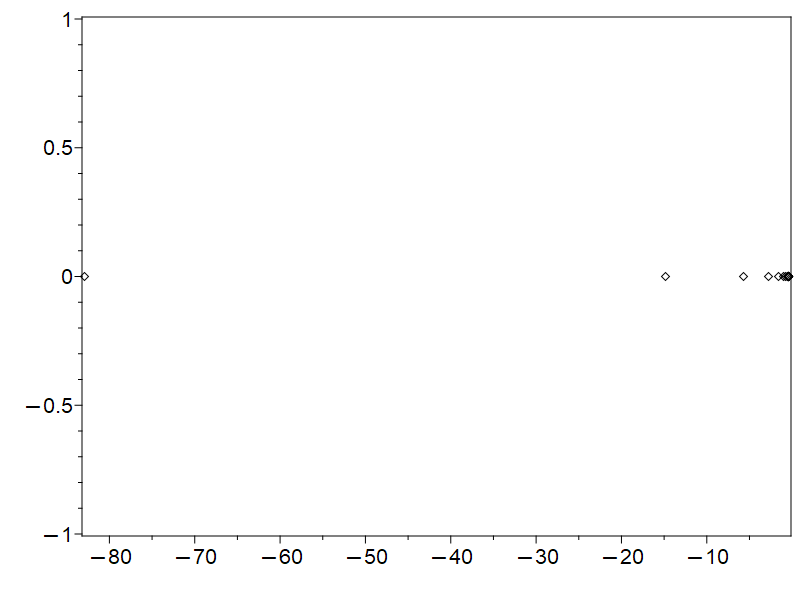

In [21]:
plots[pointplot]( [seq([Re(E[k]),Im(E[k])],k=3..numelems(E))], 
  style=point );

In [22]:
(spuriouspoles, goodpoles) := selectremove( t->(abs(Im(t))<0.01 and Re(t)>min(Z) and Re(t)<max(Z)), convert(E[3..-1],list) ):

In [23]:
numelems(spuriouspoles);

$$0$$

In [24]:
nterms := numelems(goodpoles);

$$22$$

In [25]:
Digits := 15:
asympt(leadterm(R),s);

$$ 4.41637269828905499$$

In [26]:
Digits := 30: # Most expensive step (other, cheaper, methods available)
A := Matrix(nsamples, nterms+1, (i,j)->`if`(j<=nterms,
                                     1.0/(Z[i]-goodpoles[j]), 1.0)):
alpha := CodeTools:-Usage( LeastSquares(A, F) );

memory used=1.15GiB, alloc change=58.31MiB, cpu time=9.20s, real time=7.48s, gc time=3.27s

In [27]:
latex(evalf[5](map(Re,convert(alpha,list))));

[- 171.20, - 12.524, - 2.8797, - 0.98409, - 0.40181, - 0.17812, - 0.081635, - 0.037710, - 0.017343, - 0.0079033, - 0.0035644, - 0.0015919, - 0.00070464, - 0.00030906, - 0.00013390, - 0.000056896, - 0.000023410, -{ 9.1261\times 10^{-6}}, -{ 3.2409\times 10^{-6}}, -{ 9.6897\times 10^{-7}}, -{ 2.0171\times 10^{-7}}, -{ 1.3581\times 10^{-8}},  4.4164]

In [28]:
parfrac := (s -> (alpha[nterms+1])+add( (alpha[k])/(s-(goodpoles[k])), k=1..nterms ));

s -> local k; alpha[nterms+1]+add(alpha[k]/(s-goodpoles[k]),k = 1 .. nterms)

In [29]:
alpha[nterms+1];

$$ 4.41637268198024061133710995361+ 0.0 \mathrm{I} $$

In [30]:
evalf[4](convert(spuriouspoles, list));

|
|
|


In [31]:
evalf[4](convert(goodpoles, list));

| | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-82.98+0.*I|-14.85+0.*I|-5.651+0.*I|-2.823+0.*I|-1.641+0.*I|-1.065+0.*I|-.7611+0.*I|-.5931+0.*I|-.4978+0.*I|-.4430+0.*I|-.4113+0.*I|-.3929+0.*I|-.3822+0.*I|-.3760+0.*I|-.3724+0.*I|-.3704+0.*I|-.3692+0.*I|-.3685+0.*I|-.3682+0.*I|-.3680+0.*I|-.3679+0.*I|-.3679+0.*I|


In [32]:
evalf[4](convert(alpha, list));

| | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-171.2+0.*I|-12.52+0.*I|-2.880+0.*I|-.9841+0.*I|-.4018+0.*I|-.1781+0.*I|-.8163e-1+0.*I|-.3771e-1+0.*I|-.1734e-1+0.*I|-.7903e-2+0.*I|-.3564e-2+0.*I|-.1592e-2+0.*I|-.7046e-3+0.*I|-.3091e-3+0.*I|-.1339e-3+0.*I|-.5690e-4+0.*I|-.2341e-4+0.*I|-.9126e-5+0.*I|-.3241e-5+0.*I|-.9690e-6+0.*I|-.2017e-6+0.*I|-.1358e-7+0.*I|4.416+0.*I|


In [33]:
Digits := 15;
Ez := Eigenvalues(C0z,C1z);

                                 Digits := 15

In [34]:
[seq(Im(Ez[k]),k=3..numelems(Ez))];

| | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|0.|


In [35]:
zeros := sort( [seq(Re(Ez[k]),k=3..numelems(Ez))] );

| | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-48.0306559360436|-10.4730567460214|-4.2255226970166|-2.16941327476221|-1.28844294833252|-.859890641854038|-.637319151001801|-.517558379099655|-.451767220338177|-.415140909009639|-.394566493920606|-.382935137184827|-.376328891926656|-.372566672536427|-.370425747349595|-.369215330900935|-.368541595680679|-.368178042227357|-.367993295548608|-.367910180874852|-.367882143066348|-9.36067511859643e-016|


In [36]:
Digits := 5:
lprint( evalf(map(Re,zeros)));

[-48.031, -10.473, -4.2255, -2.1694, -1.2884, -.85989, -.63732, -.51756, -.45177, -.41514, -.39457, -.38294, -.37633, -.37257, -.37043, -.36922, -.36854, -.36818, -.36799, -.36791, -.36788, -.93607e-15]

In [37]:
Digits := 30;
zeros[21], goodpoles[22], goodpoles[22]-zeros[21], -exp(-1.0)-goodpoles[22];

                                 Digits := 30

$$- 0.367882143066348144$$,$$- 0.367882129432179183+ 0.0 \mathrm{I} $$,$${ 1.3634168961\times 10^{-8}}+ 0.0 \mathrm{I} $$,$${ 2.688260736861404476229839\times 10^{-6}}- 0.0 \mathrm{I} $$

In [38]:
ns := nsamples*10:
linspace := Vector(ns, i->L + (U-L)*(i-1)/(ns-1)):
why := Vector(ns, i-> evalf((linspace[i]))):
hex := Vector(ns, i-> why[i]*exp(why[i]) ):
Digits := 30;
errs := Vector(ns, i->(why[i]-parfrac(hex[i])), datatype=complex(float)):
Digits := 15;
max(abs(errs));

                                 Digits := 15

$$ 0.000654712632625349$$

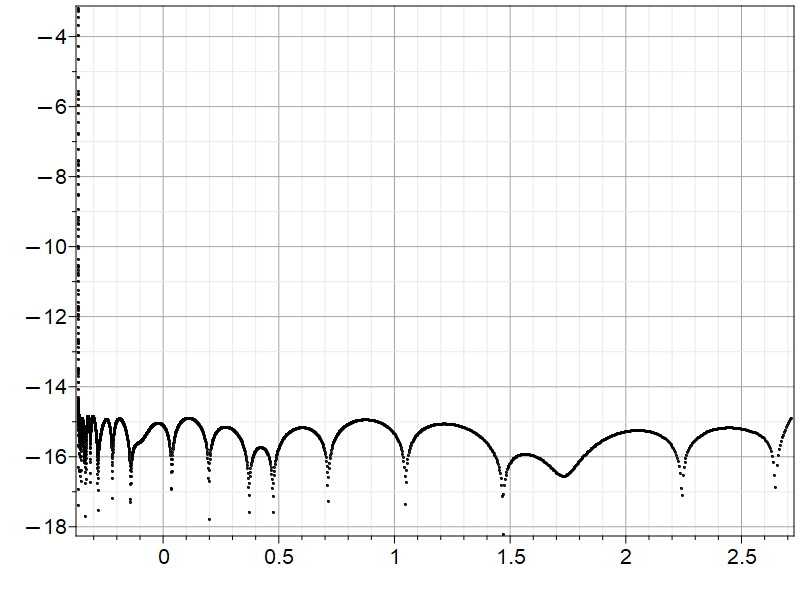

In [39]:
plots[pointplot]( [seq([hex[i], log10(abs(errs[i]))],i=2..ns)], style=point, 
                symbol=solidcircle, symbolsize=1, gridlines );

kilobytes used=254541, alloc=25866, time=17.98

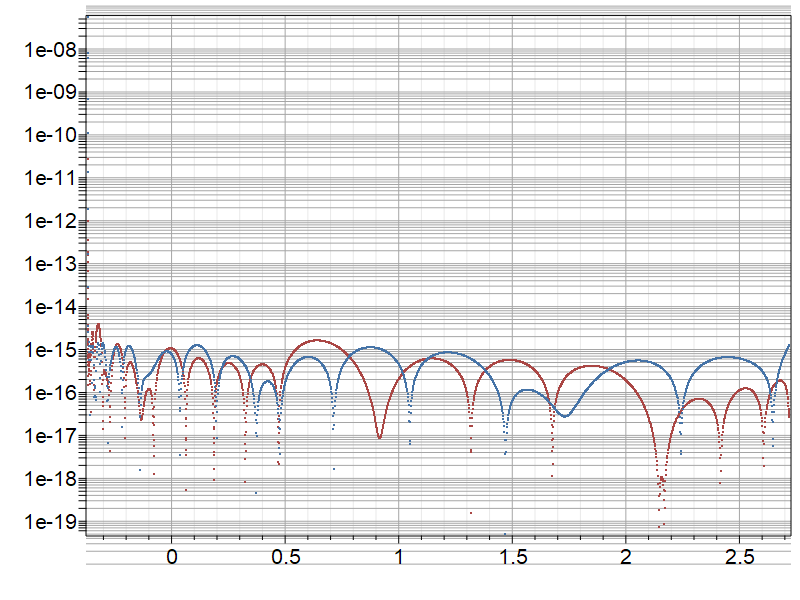

In [40]:
Digits := 30;
pgood := plots[logplot]( s->abs(parfrac(s)-LambertW(s)), min(Z)..max(Z), numpoints=2026,
                gridlines, style=point, symbol=point, colour="Executive Blue" ):
perrs := plots[logplot]( s->abs(Ro(s)-LambertW(s)), min(Z)..max(Z), numpoints=2026,
                gridlines, style=point, symbol=point, colour="Executive Red"):
plots[display](perrs,pgood);